## Alpha–proton 弹性散射：SSD 条带坐标重建反应顶点

**功能**：读取 `Vertex/Processd.root/tree`，以 11 个 SSD 条带位置特征预测世界坐标顶点 `VertexX/VertexY/VertexZ`，单位 mm；训练后保存完整模型和归一化参数，供 `VertexEvaluation.ipynb` 独立加载预测。

**方法**：uproot / awkward → NumPy float64 → 80%/20% 事件划分 → 训练集输入和三维标签分别归一化 → PyTorch float64 `11→64→64→64→3` Tanh MLP → 固定 2000 轮训练 → 测试损失监控 → 三个坐标和三维位置误差评估 → 模型保存。

**注意事项**：Cluster 四层条带位置使用世界坐标，每层保留测量 X/Y 与 Z；Recoil X1/X2/Y1 仅使用对应组的局域 X/X/Y。Left 配 RU/RD，Right 配 LU/LD。分组只参与预处理匹配，不作为模型输入；不添加 Recoil Z 或 GAGG 能量特征。训练标签取 ReactionConditions 的真实世界坐标顶点，绝不加入输入。多击中、错配与无效值在预处理阶段排除，每个原始事件最多输出一行。模型及特征仅适用于当前固定几何和配对规则；更换 Recoil 局域坐标约定后须重新训练。

输入复用 `EnergyLoss/alphap.root` 和 `EnergyLoss/alphap_test.root`，不修改 EnergyLoss 中的文件。在 MachineLearning 目录一次调用预处理，然后依次使用本 Notebook 和评估 Notebook：

```sh
root -l -b -q 'Vertex/PreProcess.C'
```

预处理顺序生成 `Vertex/Processd.root` 和 `Vertex/Processd_test.root`。Notebook 路径配置支持从 MachineLearning 或 Vertex 目录启动，模型仅写入 `Vertex/Vertex_output/VertexMLP.pt`。

依赖：uproot、awkward、numpy、torch、matplotlib。CUDA 可用时加速；MPS 不支持 float64，保持精度时使用 CPU。测试损失仅监控，不早停、不按测试损失选权重或调参，保存最后一轮模型。三维标准化损失在三个归一化输出上取平均，最终指标在反归一化后的 mm 坐标上分别计算。

MLP 和回归模式参考 `nndl-practice/pytorch/chap4前馈神经网络/前馈神经网络-上.ipynb` 及 machine-learning 技能的 `references/pytorch-examples/basics/regression/main.py`；训练、保存、独立加载结构沿用用户指定的 EnergyLoss/SSD。参考只读，不作为运行依赖。本 Notebook 交付时未执行任何单元。

**事件对齐与传统比较**：`EventID` 保持 int64，只作为文件内关联键，不作为模型特征。导出 `Vertex_output/VertexMLP_monitoring.root`，含 EventID、真实 VertexX/Y/Z 和 MLPVertexX/Y/Z。末尾单元若找到 `Tradition.root`，按 EventID 取交集并核对真实标签；传统输出只含成功事件，报告交集及未匹配数量，在同一批交集事件上比较两种方法。本 Notebook 只导出20%测试/监控事件的预测。 两个输入文件的 ID 不混用，输入更新后须重新生成相应传统与预测结果。导出会覆盖同名输出。


网络结构在模型单元显式定义；训练轮数及优化参数在训练单元定义。

In [38]:
# 功能：配置 SSD 顶点回归；方法：固定种子、输入顺序和 float64；注意事项：全部位置单位 mm，标签不参与输入。
from pathlib import Path
import random
import awkward as ak
import numpy as np
import torch
import torch.nn as nn
import uproot
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

VERTEX_DIR = Path.cwd() if Path.cwd().name == "Vertex" else Path.cwd() / "Vertex"
ROOT_PATH = VERTEX_DIR / "Processd.root"
TREE_NAME = "tree"
OUTPUT_DIR = VERTEX_DIR / "Vertex_output"
TASK_NAME = "SSD_vertex_world"
FEATURE_NAMES = ['ClusterSSDX1', 'ClusterSSDZX1', 'ClusterSSDY1', 'ClusterSSDZY1', 'ClusterSSDX2', 'ClusterSSDZX2', 'ClusterSSDY2', 'ClusterSSDZY2', 'RecoilSSDX1Locus', 'RecoilSSDX2Locus', 'RecoilSSDY1Locus']
TARGET_NAMES = ["VertexX", "VertexY", "VertexZ"]
FEATURE_UNITS = ["mm"] * len(FEATURE_NAMES)
TARGET_UNITS = ["mm"] * len(TARGET_NAMES)
SEED = 42
DTYPE = torch.float64

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(DTYPE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
elif torch.backends.mps.is_available():
    device = torch.device("cpu")
    print("MPS 可用但不支持 float64；为保持精度，使用 CPU。")
else:
    device = torch.device("cpu")
print("Device:", device, "dtype:", DTYPE)
print("Input:", ROOT_PATH.resolve())

MPS 可用但不支持 float64；为保持精度，使用 CPU。
Device: cpu dtype: torch.float64
Input: /Users/yemingxin/ROOT_Exercise/MachineLearning/Vertex/Processd.root


#### 2. 读取 ROOT 并检查事件对齐
读取 11 个坐标输入、3 个真实世界坐标标签以及仅用于结果关联的 int64 EventID。每个分支必须为每事件一个标量；遇到 NaN、Inf 或 -999 直接报错，不在 Notebook 中静默删行。预处理每个原始事件最多输出一行，因此按处理后 entry 划分即可保持事件独立；若以后输出多个候选，须按原始 EventID 分组划分，不能将同一事件的候选分到不同集合。


In [39]:
branches = FEATURE_NAMES + TARGET_NAMES
with uproot.open(ROOT_PATH) as root_file:
    tree = root_file[TREE_NAME]
    missing = [name for name in branches + ["EventID"] if name not in tree.keys()]
    if missing:
        raise KeyError(f"缺失分支: {missing}")
    entry_count = tree.num_entries
    arrays = tree.arrays(branches + ["EventID"], library="ak", how=dict)

event_ids = np.asarray(ak.to_numpy(arrays["EventID"]))
if event_ids.ndim != 1 or len(event_ids) != entry_count or event_ids.dtype != np.dtype("int64"):
    raise ValueError("EventID 必须是 Long64_t/int64 每事件标量；请先用新版 PreProcess.C 重新生成输入。")
if np.any(event_ids < 0) or np.unique(event_ids).size != len(event_ids):
    raise ValueError("EventID 必须在当前输入文件内非负且唯一。")
# EventID 保持 int64；不加入 float64 的11维特征及3维标签。

columns = {}
for name in branches:
    column = np.asarray(ak.to_numpy(arrays[name]), dtype=np.float64)
    if column.ndim != 1 or len(column) != entry_count:
        raise ValueError(f"{name} 必须是每事件一个标量，实际 shape={column.shape}")
    bad = ~np.isfinite(column) | (column == -999.0)
    if np.any(bad):
        raise ValueError(f"{name} 含无效值，entry 示例: {np.flatnonzero(bad)[:10]}")
    columns[name] = column

X = np.column_stack([columns[name] for name in FEATURE_NAMES]).astype(np.float64)
y = np.column_stack([columns[name] for name in TARGET_NAMES]).astype(np.float64)
entry_index = np.arange(entry_count, dtype=np.int64)
if entry_count < 20:
    raise ValueError("事件太少，无法建立有效的80%/20% 训练/测试划分。")
print("X:", X.shape, X.dtype, "y:", y.shape, y.dtype)
for name in branches:
    print(f"{name:22s}: min={columns[name].min():.6g}, max={columns[name].max():.6g}")

X: (6034, 11) float64 y: (6034, 3) float64
ClusterSSDX1          : min=-79.8248, max=79.8248
ClusterSSDZX1         : min=226.8, max=226.8
ClusterSSDY1          : min=-32.6092, max=34.9857
ClusterSSDZY1         : min=231.3, max=231.3
ClusterSSDX2          : min=-94.2148, max=94.8124
ClusterSSDZX2         : min=285.5, max=285.5
ClusterSSDY2          : min=-37.299, max=40.899
ClusterSSDZY2         : min=290, max=290
RecoilSSDX1Locus      : min=-39.099, max=39.099
RecoilSSDX2Locus      : min=-73.7265, max=17.5026
RecoilSSDY1Locus      : min=-39.099, max=39.099
VertexX               : min=-15.4095, max=15.436
VertexY               : min=-15.4898, max=15.3941
VertexZ               : min=-73.4928, max=51.4227


#### 3. 80%/20% 事件划分与训练集归一化
输入和 X/Y/Z 标签分别使用训练集统计量标准化，测试集复用同一组参数。保留全部指定特征，对常量输入列将标准差设为 1，并用该常量作为均值，避免浮点求和误差造成虚假缩放。输出反归一化后恢复世界坐标 mm。


In [40]:
# 与参考 Notebook 一致：独立 CPU 随机生成器固定划分索引。
split_generator = torch.Generator(device="cpu").manual_seed(SEED)
indices = torch.randperm(entry_count, generator=split_generator).numpy()
n_train = int(0.80 * entry_count)
train_idx = indices[:n_train]
test_idx = indices[n_train:]
assert len(np.unique(np.concatenate([train_idx, test_idx]))) == entry_count

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]
x_mean = X_train.mean(axis=0)
x_std_raw = X_train.std(axis=0)
constant_features = np.ptp(X_train, axis=0) == 0.0
x_mean[constant_features] = X_train[0, constant_features]
x_std = np.where(constant_features | (x_std_raw == 0.0), 1.0, x_std_raw)
y_mean = y_train.mean(axis=0)
y_std = y_train.std(axis=0)
if np.any(y_std == 0.0):
    raise ValueError("至少一个坐标标签为常量，不能按当前流程进行三维标准化。")
print("Constant features:", [FEATURE_NAMES[i] for i in np.flatnonzero(constant_features | (x_std_raw == 0.0))])
X_train_n = (X_train - x_mean) / x_std
X_test_n = (X_test - x_mean) / x_std
y_train_n = (y_train - y_mean) / y_std
y_test_n = (y_test - y_mean) / y_std
print(f"Train / test: {len(train_idx)} / {len(test_idx)}")
print("Training target mean/std (mm):", y_mean, y_std)

Constant features: ['ClusterSSDZX1', 'ClusterSSDZY1', 'ClusterSSDZX2', 'ClusterSSDZY2']
Train / test: 4827 / 1207
Training target mean/std (mm): [-0.00310626 -0.09052593  0.1387586 ] [ 6.78446249  5.3401022  19.56772037]


## 4. 张量与三输出 MLP
`11→64→64→64→3`，三个隐藏层使用 Tanh，输出线性层同时预测三个标准化的世界坐标。全部输入、标签、模型保持 float64 和同一 device。


In [41]:
def to_tensor(array):
    return torch.from_numpy(np.ascontiguousarray(array, dtype=np.float64)).to(
        device=device, dtype=DTYPE
    )

X_train_t, y_train_t = to_tensor(X_train_n), to_tensor(y_train_n)
X_test_t, y_test_t = to_tensor(X_test_n), to_tensor(y_test_n)

# 11 个条带坐标输入，3 个世界顶点坐标输出。
def build_model():
    return nn.Sequential(
        nn.Linear(11, 64), nn.Tanh(),
        nn.Linear(64, 64), nn.Tanh(),
        nn.Linear(64, 64), nn.Tanh(),
        nn.Linear(64, 3),
    )

print(build_model())

Sequential(
  (0): Linear(in_features=11, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): Tanh()
  (6): Linear(in_features=64, out_features=3, bias=True)
)


## 5. 固定轮数训练与完整集合损失监控
参考指定 Notebook：每次执行本单元重新初始化模型、优化器、学习率调度器和 DataLoader 随机生成器。固定训练 2000 epoch；不早停，不选择测试损失最小的权重。

每轮 batch 更新结束后，用相同模型状态在 `eval()` / `no_grad()` 下重新计算完整训练集和完整测试集的损失。记录梯度裁剪前范数及学习率用于诊断。测试损失只用于显示曲线。

In [ ]:
# 训练参数在训练单元内显式定义，与参考 Notebook 的安排一致。
# LEARNING_RATE = 1e-3
# MINIMUM_LEARNING_RATE = 1e-5
# epoch_count = 2000

#这种配置下MLP的效果优于传统的方法
LEARNING_RATE = 1e-3
MINIMUM_LEARNING_RATE = 1e-6
epoch_count = 5000

GRADIENT_CLIP_NORM = 1.0
BATCH_SIZE = 256
WEIGHT_DECAY = 0.0
SMOOTH_L1_BETA = 0.01  # 作用于标准化标签残差，不是 0.01 mm。

# 重新执行本单元将从固定种子和全新的优化器状态开始训练。
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
model = build_model().to(device=device, dtype=DTYPE)
criterion = nn.SmoothL1Loss(beta=SMOOTH_L1_BETA)
optimizer = torch.optim.Adam(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epoch_count, eta_min=MINIMUM_LEARNING_RATE
)
loader_generator = torch.Generator(device="cpu").manual_seed(SEED)
train_loader = DataLoader(
    TensorDataset(X_train_t.detach().cpu(), y_train_t.detach().cpu()),
    batch_size=BATCH_SIZE, shuffle=True, generator=loader_generator,
    num_workers=0, drop_last=False,
)

train_loss_history, test_loss_history = [], []
gradient_norm_history, learning_rate_history = [], []
for epoch in range(1, epoch_count + 1):
    model.train()
    gradient_norm_sum = 0.0
    batch_count = 0
    for xb, yb in train_loader:
        xb = xb.to(device=device, dtype=DTYPE)
        yb = yb.to(device=device, dtype=DTYPE)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        if not torch.isfinite(loss).item():
            raise RuntimeError("训练损失出现 NaN/Inf。")
        loss.backward()
        gradient_norm = nn.utils.clip_grad_norm_(
            model.parameters(), GRADIENT_CLIP_NORM, error_if_nonfinite=True
        )
        optimizer.step()
        gradient_norm_sum += float(gradient_norm.detach().cpu())
        batch_count += 1

    model.eval()
    with torch.no_grad():
        train_loss = criterion(model(X_train_t), y_train_t).item()
        test_loss = criterion(model(X_test_t), y_test_t).item()
    if not np.isfinite(train_loss) or not np.isfinite(test_loss):
        raise RuntimeError("完整集合评估损失出现 NaN/Inf。")
    train_loss_history.append(train_loss)
    test_loss_history.append(test_loss)
    gradient_norm_history.append(gradient_norm_sum / batch_count)
    learning_rate_history.append(optimizer.param_groups[0]["lr"])
    scheduler.step()
    if epoch == 1 or epoch % 200 == 0:
        print(f"Epoch {epoch:4d}/{epoch_count}: train={train_loss:.6g}, "
              f"test={test_loss:.6g}, gradient norm={gradient_norm_history[-1]:.6g}, "
              f"lr={learning_rate_history[-1]:.2e}")

epoch_count = len(train_loss_history)
model.eval()
print(f"Finished {epoch_count} epochs; using final model weights.")

Epoch    1/5000: train=0.554843, test=0.554319, gradient norm=0.282692, lr=1.00e-03
Epoch  200/5000: train=0.0413475, test=0.0414114, gradient norm=3.54646, lr=9.96e-04
Epoch  400/5000: train=0.0366449, test=0.0377652, gradient norm=3.84085, lr=9.84e-04
Epoch  600/5000: train=0.0294933, test=0.0307544, gradient norm=3.4915, lr=9.65e-04
Epoch  800/5000: train=0.0297017, test=0.030801, gradient norm=3.69421, lr=9.38e-04
Epoch 1000/5000: train=0.0291541, test=0.0302441, gradient norm=3.83337, lr=9.05e-04
Epoch 1200/5000: train=0.0274113, test=0.0281381, gradient norm=3.51833, lr=8.65e-04
Epoch 1400/5000: train=0.0289226, test=0.0295736, gradient norm=4.31917, lr=8.19e-04
Epoch 1600/5000: train=0.0257129, test=0.0272774, gradient norm=3.42587, lr=7.68e-04
Epoch 1800/5000: train=0.0233184, test=0.0245334, gradient norm=3.56612, lr=7.13e-04
Epoch 2000/5000: train=0.026384, test=0.0270936, gradient norm=3.41432, lr=6.55e-04
Epoch 2200/5000: train=0.0232519, test=0.0244087, gradient norm=4.329

## 6. 单独绘制损失曲线
两条曲线均为每轮结束时同一模型状态下的完整集合损失，纵轴为标准化 SmoothL1 loss。

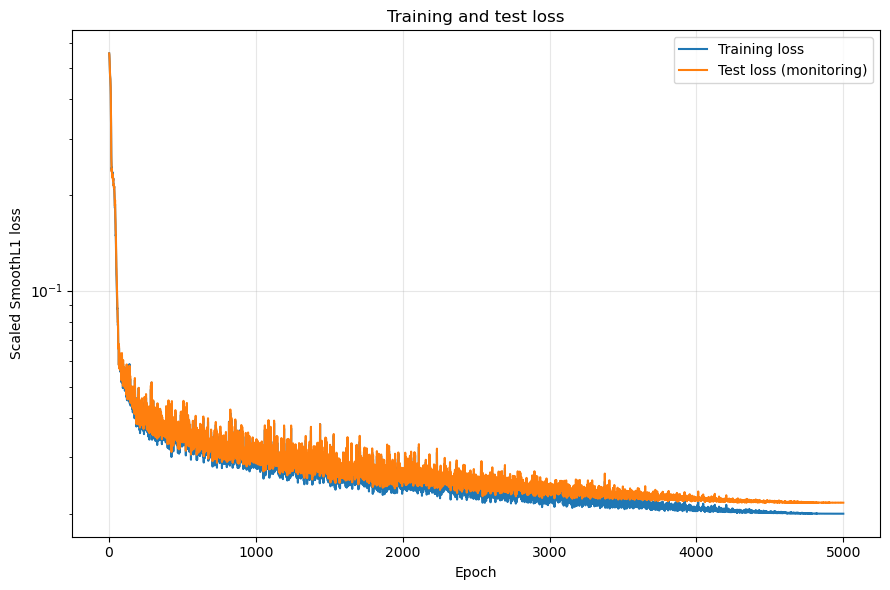

In [43]:
epochs = np.arange(1, epoch_count + 1)
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(epochs, train_loss_history, label="Training loss")
ax.plot(epochs, test_loss_history, label="Test loss (monitoring)")
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Scaled SmoothL1 loss")
ax.set_title("Training and test loss")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## 7. 三个坐标与三维位置误差（mm）
残差定义为预测 − 真值。按 X/Y/Z 分别报告 MSE、RMSE、MAE、R²、Bias、残差标准差及中间 68% 残差半宽；再报告三维欧氏距离的均值、RMSE 和 68%/95% 分位数。所有指标使用全部测试/监控事件。残差直方图显示 [-20,20] mm、bin 宽 0.5 mm，范围外事件计入指标但不显示。测试集仅用于固定轮数训练后的监控与评估，不参与权重选择。


Evaluated events: 1207
VertexX
  MSE_mm2                 : 0.0610196
  RMSE_mm                 : 0.247022
  MAE_mm                  : 0.191118
  R2                      : 0.998724
  Bias_mm                 : 0.000127641
  ResidualStd_mm          : 0.247022
  Central68HalfWidth_mm   : 0.229989
VertexY
  MSE_mm2                 : 0.0748763
  RMSE_mm                 : 0.273635
  MAE_mm                  : 0.214035
  R2                      : 0.997339
  Bias_mm                 : -0.00739299
  ResidualStd_mm          : 0.273535
  Central68HalfWidth_mm   : 0.261799
VertexZ
  MSE_mm2                 : 0.0776166
  RMSE_mm                 : 0.278598
  MAE_mm                  : 0.193249
  R2                      : 0.999784
  Bias_mm                 : -0.00652404
  ResidualStd_mm          : 0.278521
  Central68HalfWidth_mm   : 0.228749
3D world-position error:
  MeanDistance_mm         : 0.399457
  RMSEDistance_mm         : 0.462074
  Q68Distance_mm          : 0.44486
  Q95Distance_mm          : 0

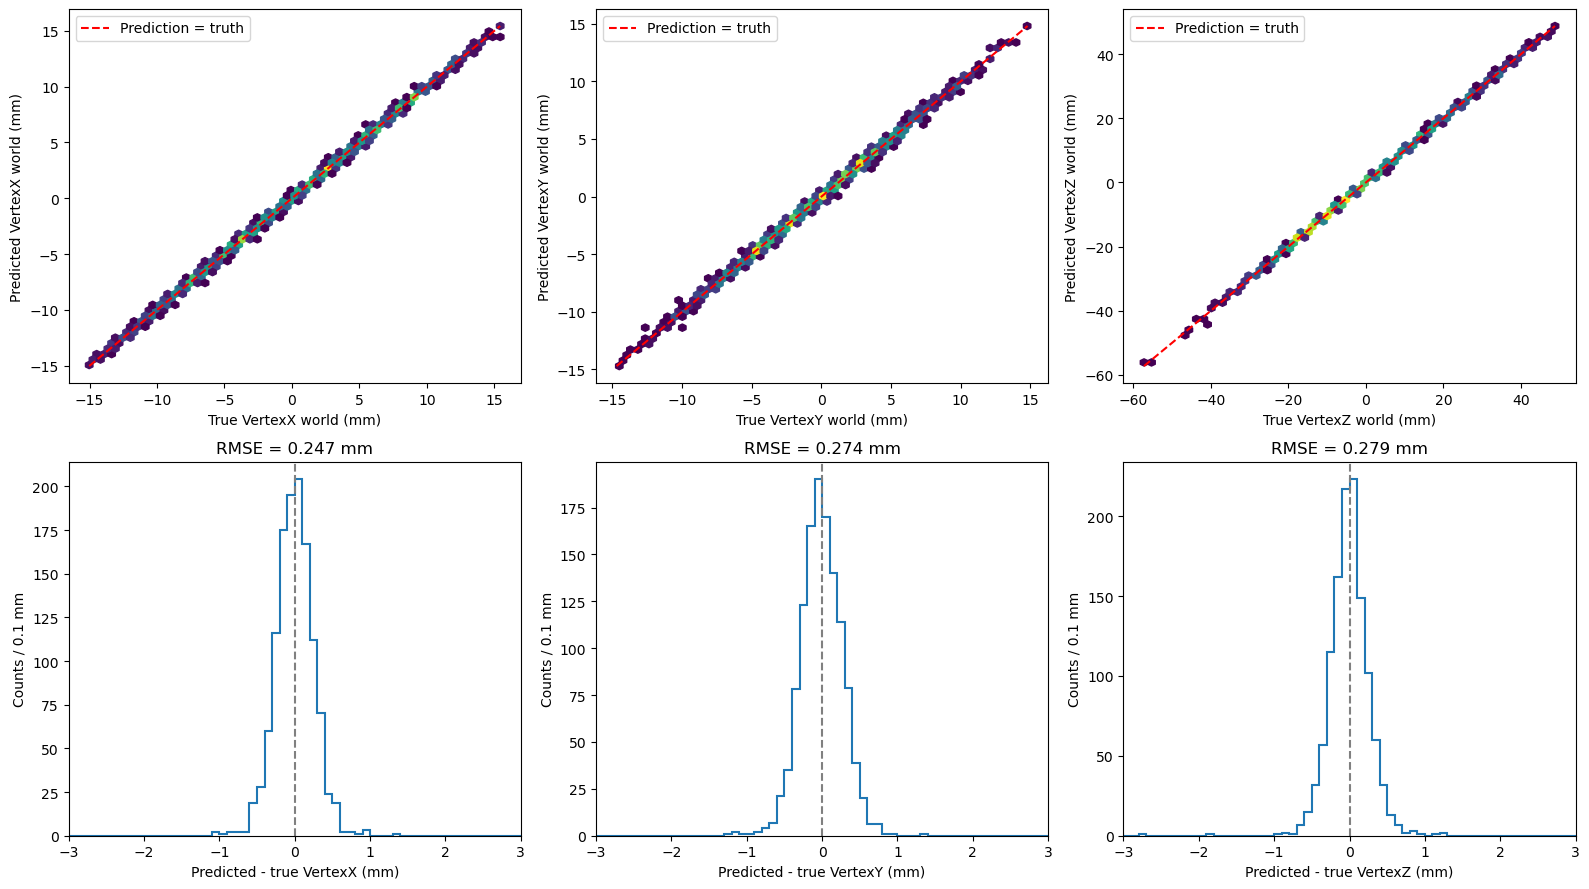

In [44]:
model.eval()
with torch.no_grad():
    pred_n = model(X_test_t).cpu().numpy()
pred = pred_n * y_std + y_mean
if not np.all(np.isfinite(pred)):
    raise RuntimeError("测试顶点预测包含 NaN/Inf。")
y_true = y_test
residual = pred - y_true

def vertex_metrics(truth, prediction):
    difference = prediction - truth
    rows = {}
    for axis, name in enumerate(TARGET_NAMES):
        r = difference[:, axis]
        mse = float(np.mean(r ** 2))
        ss_tot = float(np.sum((truth[:, axis] - truth[:, axis].mean()) ** 2))
        q16, q84 = np.quantile(r, [0.16, 0.84])
        rows[name] = {
            "MSE_mm2": mse,
            "RMSE_mm": float(np.sqrt(mse)),
            "MAE_mm": float(np.mean(np.abs(r))),
            "R2": 1.0 - float(np.sum(r ** 2)) / ss_tot if ss_tot > 0 else np.nan,
            "Bias_mm": float(r.mean()),
            "ResidualStd_mm": float(r.std()),
            "Central68HalfWidth_mm": float((q84 - q16) / 2.0),
        }
    distance = np.linalg.norm(difference, axis=1)
    distance_metrics = {
        "MeanDistance_mm": float(distance.mean()),
        "RMSEDistance_mm": float(np.sqrt(np.mean(distance ** 2))),
        "Q68Distance_mm": float(np.quantile(distance, 0.68)),
        "Q95Distance_mm": float(np.quantile(distance, 0.95)),
    }
    return rows, distance_metrics

metrics, distance_metrics = vertex_metrics(y_true, pred)
print(f"Evaluated events: {len(y_true)}")
for name, values in metrics.items():
    print(name)
    for key, value in values.items():
        print(f"  {key:24s}: {value:.6g}")
print("3D world-position error:")
for key, value in distance_metrics.items():
    print(f"  {key:24s}: {value:.6g}")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
residual_bins = np.arange(-5.0, 5.0 + 0.5, 0.1)
for axis, name in enumerate(TARGET_NAMES):
    ax = axes[0, axis]
    ax.hexbin(y_true[:, axis], pred[:, axis], gridsize=55, mincnt=1, cmap="viridis")
    lo = min(y_true[:, axis].min(), pred[:, axis].min())
    hi = max(y_true[:, axis].max(), pred[:, axis].max())
    ax.plot([lo, hi], [lo, hi], "r--", label="Prediction = truth")
    ax.set_xlabel(f"True {name} world (mm)")
    ax.set_ylabel(f"Predicted {name} world (mm)")
    ax.legend()
    ax = axes[1, axis]
    _, bin_edges, _ = ax.hist(residual[:, axis], bins=residual_bins, histtype="step", linewidth=1.5)
    ax.set_xlim(-3, 3)
    ax.set_xlabel(f"Predicted - true {name} (mm)")
    ax.set_ylabel(f"Counts / {bin_edges[1] - bin_edges[0]:.3g} mm")
    ax.axvline(0.0, color="gray", linestyle="--")
    ax.set_title(f"RMSE = {metrics[name]['RMSE_mm']:.3g} mm")
fig.tight_layout()
plt.show()


## 8. 保存模型和训练集预处理
保存完整模型、11 个输入的顺序、3 个标签的顺序、单位、坐标系约定和训练集归一化参数。评估 Notebook 直接加载，不重建网络、不重新训练，也不从测试数据估计归一化参数。


In [45]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
model.eval()
torch.save(
    {
        "model": model,
        "task": TASK_NAME,
        "feature_names": FEATURE_NAMES,
        "target_names": TARGET_NAMES,
        "feature_units": FEATURE_UNITS,
        "target_units": TARGET_UNITS,
        "coordinate_systems": {"ClusterSSD": "world", "RecoilSSD": "locus", "Vertex": "world"},
        "x_mean": x_mean, "x_std": x_std,
        "y_mean": y_mean, "y_std": y_std,
    },
    OUTPUT_DIR / "VertexMLP.pt",
)
print("Saved:", (OUTPUT_DIR / "VertexMLP.pt").resolve())


Saved: /Users/yemingxin/ROOT_Exercise/MachineLearning/Vertex/Vertex_output/VertexMLP.pt


RMSE 对少量大残差更敏感；MAE 描述平均绝对偏差；Bias 描述坐标的整体偏移。三个坐标的误差分别以 mm 报告，不能将三维欧氏距离的 RMSE 与单个坐标的 RMSE 混为一谈。


## EventID 预测导出与传统方法对比

先运行前面的预测和误差评估单元。Tradition.C 独立遍历原始文件且只保存成功事件，传统结果存在时按 EventID 取交集比较。未匹配事件可能被筛除或几何重建失败，不能仅凭缺失 ID 区分原因。


MLP评估事件=1207，传统成功事件=6034，共同事件=1207，未匹配传统结果=0
VertexX MLP: RMSE=0.247022 mm，显示范围外事件=0
VertexX Tradition: RMSE=0.256969 mm，显示范围外事件=0
VertexY MLP: RMSE=0.273635 mm，显示范围外事件=0
VertexY Tradition: RMSE=0.289665 mm，显示范围外事件=0
VertexZ MLP: RMSE=0.278598 mm，显示范围外事件=1
VertexZ Tradition: RMSE=0.295085 mm，显示范围外事件=1


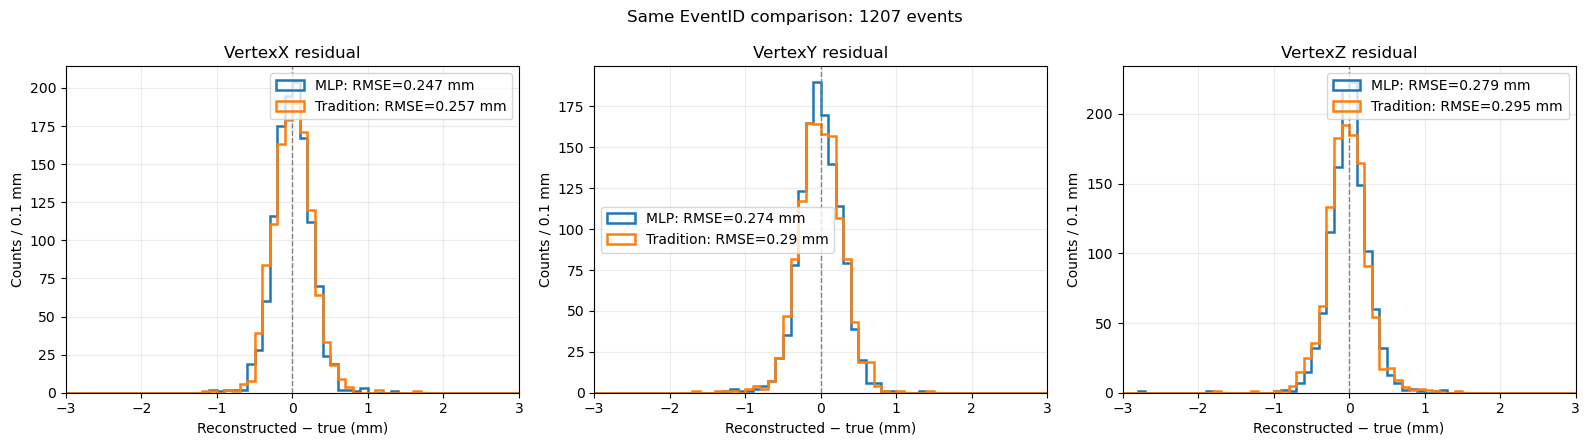

In [46]:
# 功能：按 EventID 对齐共同事件，叠加绘制 MLP 和传统方法的世界坐标 XYZ 残差。
# 方法：两种方法使用同一批事件；残差为重建值减真值。
# 注意事项：只在 Notebook 显示，不写本地文件；显示范围 [-3, 3] mm，
#           bin 宽度 0.1 mm，横轴主刻度间隔 1 mm；RMSE 使用全部共同事件。

from matplotlib.ticker import MultipleLocator

ml_event_ids = event_ids[test_idx]
tradition_path = VERTEX_DIR / "Tradition.root"

if not tradition_path.exists():
    raise FileNotFoundError(f"请先生成传统重建结果：{tradition_path}")

comparison_branches = (
    ["EventID"]
    + TARGET_NAMES
    + ["Tradition" + name for name in TARGET_NAMES]
)
with uproot.open(tradition_path) as tradition_file:
    tradition_arrays = tradition_file["tree"].arrays(
        comparison_branches, library="np"
    )

traditional_ids = tradition_arrays["EventID"]
for label, ids in [("MLP", ml_event_ids), ("Tradition", traditional_ids)]:
    if ids.ndim != 1 or ids.dtype != np.dtype("int64"):
        raise ValueError(f"{label} EventID 必须是 int64 标量。")
    if np.any(ids < 0) or np.unique(ids).size != len(ids):
        raise ValueError(f"{label} EventID 无效或重复。")

if (
    y_true.ndim != 2
    or y_true.shape[1] != 3
    or len(ml_event_ids) != len(y_true)
    or pred.shape != y_true.shape
):
    raise ValueError("MLP 的 EventID、真实顶点与预测顶点不对应。")

lookup = {int(event_id): i for i, event_id in enumerate(traditional_ids)}
ml_rows = np.array(
    [
        i for i, event_id in enumerate(ml_event_ids)
        if int(event_id) in lookup
    ],
    dtype=np.int64,
)
tradition_rows = np.array(
    [lookup[int(ml_event_ids[i])] for i in ml_rows],
    dtype=np.int64,
)

print(
    f"MLP评估事件={len(ml_event_ids)}，"
    f"传统成功事件={len(traditional_ids)}，"
    f"共同事件={len(ml_rows)}，"
    f"未匹配传统结果={len(ml_event_ids) - len(ml_rows)}"
)

if len(ml_rows) == 0:
    raise ValueError("没有共同 EventID，请确认结果来自同一原始文件。")

common_truth = y_true[ml_rows]
ml_prediction = pred[ml_rows]
traditional_truth = np.column_stack([
    tradition_arrays[name][tradition_rows]
    for name in TARGET_NAMES
])
traditional_prediction = np.column_stack([
    tradition_arrays["Tradition" + name][tradition_rows]
    for name in TARGET_NAMES
])

for values in [
    common_truth, traditional_truth,
    ml_prediction, traditional_prediction,
]:
    if np.any(~np.isfinite(values)) or np.any(values == -999.0):
        raise ValueError("共同事件中存在无效顶点。")

if not np.allclose(
    traditional_truth, common_truth, rtol=0.0, atol=1e-9
):
    raise ValueError("同一 EventID 的真实顶点不同，请检查输入来源。")

ml_residual = ml_prediction - common_truth
traditional_residual = traditional_prediction - common_truth

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
bins = np.linspace(-3.0, 3.0, 61)

for axis, ax in enumerate(axes):
    for label, residuals, color in [
        ("MLP", ml_residual, "tab:blue"),
        ("Tradition", traditional_residual, "tab:orange"),
    ]:
        values = residuals[:, axis]
        rmse = np.sqrt(np.mean(values**2))
        outside = np.count_nonzero((values < -3.0) | (values > 3.0))
        print(
            f"{TARGET_NAMES[axis]} {label}: "
            f"RMSE={rmse:.6g} mm，显示范围外事件={outside}"
        )
        ax.hist(
            values,
            bins=bins,
            histtype="step",
            linewidth=1.8,
            color=color,
            label=f"{label}: RMSE={rmse:.3g} mm",
        )

    ax.axvline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(-3.0, 3.0)
    ax.xaxis.set_major_locator(MultipleLocator(1.0))
    ax.set_title(f"{TARGET_NAMES[axis]} residual")
    ax.set_xlabel("Reconstructed − true (mm)")
    ax.set_ylabel("Counts / 0.1 mm")
    ax.legend()
    ax.grid(alpha=0.25)

fig.suptitle(f"Same EventID comparison: {len(ml_rows)} events")
fig.tight_layout()
plt.show()
